In [2]:
import gymnasium as gym
from gymnasium import spaces
import math
import numpy as np
import random
import matplotlib
import matplotlib.pyplot as plt
from collections import namedtuple, deque
from itertools import count
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from treys import Card, Deck, Evaluator

evalu = Evaluator()

# -----------------------------------------------------------
# Monte Carlo Equity Calculator
# -----------------------------------------------------------

def simulate_preflop(h1, h2):

    your_hand = [Card.new(h1), Card.new(h2)]

    count = 0


    N = 2000  

    for i in range(N):
        deck = Deck()

        # remove hero hand from deck
        deck.cards.remove(your_hand[0])
        deck.cards.remove(your_hand[1])

        villain_hand = deck.draw(2)
        board = deck.draw(5)

        hero_score = evalu.evaluate(board, your_hand)
        villain_score = evalu.evaluate(board, villain_hand)


        if villain_score > hero_score:
            count += 1
        else:
            pass

    win_rate = count / N


    return win_rate

def simulate_preturn(h1, h2, b1, b2, b3):

    your_hand = [Card.new(h1), Card.new(h2)]
    flop = [Card.new(b1), Card.new(b2), Card.new(b3)]

    count = 0

    N = 2000

    for i in range(N):
        deck = Deck()

        # remove hero cards and flop cards
        deck.cards.remove(your_hand[0])
        deck.cards.remove(your_hand[1])
        for c in flop:
            deck.cards.remove(c)

        villain_hand = deck.draw(2)
        turn_river = deck.draw(2)
        board = flop + turn_river

        hero_score = evalu.evaluate(board, your_hand)
        villain_score = evalu.evaluate(board, villain_hand)


        if villain_score > hero_score:
            count += 1
        else:
            pass

    win_rate = count / N


    return win_rate

def simulate_preriver(h1, h2, b1, b2, b3, b4):

    your_hand = [Card.new(h1), Card.new(h2)]
    flop_turn = [
        Card.new(b1), 
        Card.new(b2), 
        Card.new(b3), 
        Card.new(b4)
    ]

    count = 0

    N = 2000

    for i in range(N):
        deck = Deck()

        deck.cards.remove(your_hand[0])
        deck.cards.remove(your_hand[1])

        for c in flop_turn:
            deck.cards.remove(c)

        villain_hand = deck.draw(2)
        river = deck.draw(1)
        board = flop_turn + river

        hero_score = evalu.evaluate(board, your_hand)
        villain_score = evalu.evaluate(board, villain_hand)


        if villain_score > hero_score:
            count += 1
        else:
            pass

    win_rate = count / N

    return win_rate

def simulate_prereveal(h1, h2, b1, b2, b3, b4, b5):

    your_hand = [Card.new(h1), Card.new(h2)]
    board = [
        Card.new(b1),
        Card.new(b2),
        Card.new(b3),
        Card.new(b4),
        Card.new(b5)
    ]

    hero_score = evalu.evaluate(board, your_hand)

    count = 0

    N = 2000

    for i in range(N):
        deck = Deck()
        deck.cards.remove(your_hand[0])
        deck.cards.remove(your_hand[1])
        for card in board:
            deck.cards.remove(card)
            
        villain_hand = deck.draw(2)

        villain_score = evalu.evaluate(board, villain_hand)

        if villain_score > hero_score:
            count += 1
        else:
            pass

    win_rate = count / N

    return win_rate


# -----------------------------------------------------------
# Environment 
# -----------------------------------------------------------
"""
Notes for Poker class:
This is the third iteration of the environment, although past environments have worked they were working on poor game mechanics,
as well as hitting a plateu on the rewards at around 0.02 (normalized) chips per game, on a set amount of the stack.
The step function's step was one betting round at any given street. On this iteration, I made the stack a random number between 
100, and 500 (since this is a reasonable range for casual play), and the step is only one action (of the hero, as well as the 
opponent's response).
I might add another observation element - that being a boolean flag of if the betting round is live or not.
Nevertheless, I've given the observation vector more elements, and made the step function more simple. I believe this will 
lead to the bot learning the overpowered strategies its supposed to a lot slower, as I will need a lot more episodes to compensate
for this increase in information the network will be handling. 
Furthermore, I've implemented some strategies like pot odds, and reward shaping to help push it past that 0.02 chips per game.
"""

class Poker(gym.Env):
    def __init__(self):
        """
        Notes for __init__ function:
        Pot, hero stack, effective stack, are normalized by using rate-based adjustment - dividing by starting stack. 
        While starting stack is normalized by using min-max rescaling - x - x_min/ x_max - x_min.
        """
        super().__init__()

        self.observation_space = spaces.Box(
            low = np.array([
                0.0, # win rate
                0.0, # starting stack (starting stacks are equal for both opp and hero)
                0.0, # pot
                0.0, # hero stack
                0.0, # effective stack
                0.0, # position
                0.0, # pot odds
                0.0, # opp agg
                0.0, # street
                0.0,  # opp last action
                0.0
            ], dtype = np.float32),
            high = np.array([
                1.0,
                1.0, 
                1.0,
                1.0,
                1.0,
                1.0,
                1.0,
                5.0,
                1.0,
                6.0,
                1.0
            ], dtype = np.float32),
            dtype = np.float32
        )

        self.action_space = spaces.Discrete(7) # 0 -> fold, 1 -> check/call, 2 -> bet 33% of pot, 3 -> bet 67% of pot, 4 -> bet 100% of pot, 5 -> bet 150% of pot, 5 -> all-in
        
        self.button = None # 0 for small blind, 1 for big blind
        self.small_blind = None # will be set to 0.02x of stack
        self.big_blind = None # big blind is 2x small blind
        self.stack = None # will be randomly set within a normal range

        self.deck = None
        self.street = None # 0 --> preflop, 1 --> after flop, 2 --> after turn, 3 --> after after river
        self.board = None
        self.number_of_actions = None
        self.h1 = None
        self.h2 = None

        self.opp_stack = None
        self.opp_raises = None
        self.opp_calls = None
        self.opp_action = None
       
        self.bet_amount = None # bet amount (will be on big blind for every street except 0th - preflop)
        self.bet_history = None # will be a list of current bet and bet on the last iteration, can get call/raise amounts, and a chekc if betting is finished
       
        self.chips_to_pot = None # chips betting is symmetric so we only need one, must createa  funciton that checks if other person calls though
        self.pot = None
        
        self.hero_stack = None
        self.win_rate = None
    
        self.betting_ongoing = None # will be a boolean flag telling us if a betting round is going on, 0 for no, 1 for yes
        self.turn = None # will be used while betting_live is true, 0 for hero, 1 for opp

        self.hero_contribution = None
        self.opp_contribution = None

    def _get_obs(self):
        
        call_amount = self.opp_contribution - self.hero_contribution
        
        if (call_amount + self.pot) == 0:
            pot_odds = 0
        else:
            pot_odds = call_amount / (self.pot + call_amount)

        opp_agg = min(self.opp_raises / max(self.opp_calls, 1), 5)
        return np.array([
            self.win_rate, 
            (self.stack - 100) / 400,
            self.pot / (2 * self.stack), # normalized pot
            self.hero_stack / self.stack, # normalized hero stack
            min(self.hero_stack, self.opp_stack) / self.stack, # normalized effective stack
            self.button,
            pot_odds, # pot odds (doesn't inlcude opponent last bet as it is already accounted for in the pot)
            opp_agg, 
            self.street / 3,
            self.opp_action,
            self.betting_ongoing
        ], dtype = np.float32)


    def reset(self, seed = None, options = None):
        super().reset(seed=seed)
        
        self.deck = Deck()
        self.board = []

        hero_cards = self.deck.draw(2)
        self.h1 = Card.int_to_str(hero_cards[0])
        self.h2 = Card.int_to_str(hero_cards[1])
    
        self.button = random.randint(0,1)
        self.street = 0
        self.betting_ongoing = False
        self.number_of_actions = 0
        
        self.stack = random.randint(100, 500)
        self.hero_stack = self.stack
        self.opp_stack = self.stack
        self.small_blind = self.stack * 0.02
        self.big_blind = 2 * self.small_blind

        self.opp_action = 1
        self.opp_raises = 0
        self.opp_calls = 0

        self.bet_amount = 0
        self.chips_to_pot = 0
        self.pot = 0

        self.hero_contribution = 0.0
        self.opp_contribution = 0.0

        self.post_blinds()
        
        self.compute_win_rate()
        observation = self._get_obs()

        return observation, {}

    def step(self, action):
        terminated = False
        truncated = False

        hero_fold = self.apply_action(action)

        if hero_fold == True:
            terminated = True
            reward, _ = self.get_reward(action)
            observation = self._get_obs()
            return observation, reward, terminated, truncated, {}

        move = self.done(action)

        if move == "advance":
            self.advance_street(move)

            if self.street > 3:
                terminated = True
                reward, winner = self.get_reward(action, True)
                observation = self._get_obs()
                
                return observation, reward, terminated, truncated, {}
                
        self.compute_win_rate()

        while not terminated:
            self.whos_turn()

            if self.turn == 0:
                break

            opp_action = self.opp()
            self.opp_action = opp_action
            
            if opp_action == 0:
                terminated = True
                reward, _ = self.get_reward(action)
                observation = self._get_obs()

                return observation, reward, terminated, truncated, {}

            move = self.done(None)

            if move == "advance":
                self.advance_street(move)

                if self.street > 3:
                    terminated = True
                    reward, winner = self.get_reward(action, True)
                    observation = self._get_obs()

                    return observation, reward, terminated, truncated, {}

                self.compute_win_rate()
                
        reward = self.reward_shaping(action)
        observation = self._get_obs()

        return observation, reward, terminated, truncated, {}
        

    def advance_street(self, move):
        """
        Notes for advance_street function:
        This function will advance the street and reset all respective variables
        This function will be called after betting is done and will take in the flag the done function gives
        """
        if move == "advance":
            self.street += 1
            self.hero_contribution = self.small_blind
            self.opp_contribution = self.big_blind
            self.chips_to_pot = 0
            self.number_of_actions = 0
            
            if self.street == 1:
                self.board.extend(self.deck.draw(3))

            elif self.street == 2:
                self.board.extend(self.deck.draw(1))

            elif self.street == 3:
                self.board.extend(self.deck.draw(1))

        
    def compute_win_rate(self):
        """ 
        Notes for compute_win_rate function:
        Don't know if I need return statement since the variable being updated is global (within the class)
        """
        if self.street == 0:
            self.win_rate = simulate_preflop(self.h1, self.h2)
            return self.win_rate
            
        elif self.street == 1:
            board = [Card.int_to_str(card) for card in self.board]
            self.win_rate = simulate_preturn(self.h1, self.h2, board[0], board[1], board[2])
            return self.win_rate
            
        elif self.street == 2:
            board = [Card.int_to_str(card) for card in self.board]
            self.win_rate = simulate_preriver(self.h1, self.h2, board[0], board[1], board[2], board[3])
            return self.win_rate
        else:
            board = [Card.int_to_str(card) for card in self.board]
            self.win_rate = simulate_prereveal(self.h1, self.h2, board[0], board[1], board[2], board[3], board[4])
            return self.win_rate

            
    def post_blinds(self):
        if self.button == 0:
            if self.street == 0:
                self.chip_mover("hero",self.small_blind)
                self.chip_mover("opp", self.big_blind)
                self.opp_contribution += self.big_blind
                self.hero_contribution += self.small_blind
        else:
            if self.street == 0:
                self.chip_mover("opp", self.small_blind)
                self.chip_mover("hero", self.big_blind)
                self.opp_contribution += self.small_blind
                self.hero_contribution += self.big_blind
            
    def first_to_act(self):
        """
        Notes for first_to_act function:
        Can we negate the while loops entirely?
        This function will return who is first to act at the beginning of each street
        This function should be called after the incremation of the street in step()
        """
        if self.button == 0:
            if self.street == 0:
                self.turn = 0
                self.betting_ongoing = True
                return "hero"
            else:
                while self.street in (1,2,3):
                    self.betting_ongoing = True
                    self.turn = 1
                    return "opp"
        else:
        # opponent has button
            if self.street == 0:
                self.betting_ongoing = True
                self.turn = 1
                return "opp"
            else:
                while self.street in (1,2,3):
                    self.betting_ongoing = True
                    self.turn = 0
                    return "hero"

                    
    def whos_turn(self):
        """
        Notes for whos_turn function:
        This function updates who's turn it is given any street, and any position of the betting round
        This function will be called in step and relies on self.turn
        """
        if self.turn is None:
            first = self.first_to_act()
            self.turn = 0 if first == "hero" else 1
            
        if not self.betting_ongoing:
            first = self.first_to_act()
            self.turn = 0 if first == "hero" else 1

        else:
            self.turn = 1 - self.turn


    def done(self, action):
        """
        Notes for done function:
        This function will update self.betting_end and will take in hero's action to do so, and return advance flag for advance_street
        This means the function will be called after the heros action AND after the opponents'
        """
        call_amount = abs(self.hero_contribution - self.opp_contribution)
        self.number_of_actions += 1

        if self.number_of_actions < 2 or call_amount != 0:
            self.betting_ongoing = True
        else:
            self.betting_ongoing = False
            return "advance"


    def chip_mover(self, player, amount):
        """
        Notes for chip_mover function:
        This function will update stacks and pot for the respective case
        This function should be used in opponent model as well as apply_action function
        """
        if player == "hero":
            self.hero_stack -= amount
            self.pot += amount
        else:
            self.opp_stack -= amount
            self.pot += amount


    def opp(self):
        """
        Notes for opp function:
        This function will model opponent actions, and execute the respective consequence
        This function should be used in step()
        Eventually should implement stochastics where a high opponent aggression increases the probablility for raises
        """
        action = random.randint(0,6)

        if action == 0:
            return 0
            
        elif action == 1:
            bet_amount = self.hero_contribution - self.opp_contribution
            
        elif action in (2, 3, 4, 5):
            call_amount = self.hero_contribution - self.opp_contribution

            if action == 2:
                bet_amount = call_amount + 0.33*self.pot
                
            elif action == 3:
                bet_amount = call_amount + 0.67*self.pot
                
            elif action == 4:
                bet_amount = call_amount + self.pot
                
            elif action == 5:
                bet_amount = call_amount + 1.25*self.pot
                
        elif action == 6:
            bet_amount = self.opp_stack

        bet_amount = min(bet_amount, self.opp_stack)
        self.opp_contribution += bet_amount
        self.chip_mover("opp", bet_amount)
        
        return action

    def apply_action(self, action):
        """
        Notes for apply_action function:
        This function applies respective consequences of whatever action the agent chooses
        while returning if it has folded or not
        """

        if action == 0:
            return True
            
        elif action == 1:
            bet_amount = self.opp_contribution - self.hero_contribution
            
        elif action in (2, 3, 4, 5):
            call_amount = self.opp_contribution - self.hero_contribution

            if action == 2:
                bet_amount = call_amount + 0.33*self.pot
                
            elif action == 3:
                bet_amount = call_amount + 0.67*self.pot
                
            elif action == 4:
                bet_amount = call_amount + self.pot
                
            elif action == 5:
                bet_amount = call_amount + 1.25*self.pot
                
        elif action == 6:
            bet_amount = self.hero_stack

        bet_amount = min(bet_amount, self.hero_stack)
        self.hero_contribution += bet_amount
        self.chip_mover("hero", bet_amount)
        
        return False


    def showdown(self):
        """
        Notes for showdown function:
        This function just tells us if opponent wins or loses once termination occurs
        """
        opp_hand = self.deck.draw(2) 
        opp_score = evalu.evaluate(self.board, opp_hand)
        hero_score = evalu.evaluate(self.board, [Card.new(self.h1), Card.new(self.h2)])

        if opp_score < hero_score:
            
            return "loss"
            
        elif hero_score < opp_score:
            
            return "win"
            
        else:

            return None

        
    def reward_shaping(self, action):
        """
        Notes for reward_shaping function:
        This function will reinforce good strategy. as well as penalize dumb actions
        This function should be called inside the actual reward function
        """
        call_amount = abs(self.hero_contribution - self.opp_contribution)
        reward = 0
        scale = 0.3
        
        if self.pot + call_amount == 0.0:
            pot_odds = 0.0
        else:
            pot_odds = call_amount / (self.pot + call_amount)

            
        edge = self.win_rate - pot_odds

        if action == 0:
            reward = -edge

        else:
            reward = edge

        return reward*scale


    def get_reward(self, hero_action, showdown=None):
        if showdown == True:
            result = self.showdown()
        else:
            result = None
        
        if result == "win" or self.opp_action == 0 or self.opp_action == None:
            reward = (self.hero_stack + self.pot) - self.stack
        elif result == "loss" or hero_action == 0:
            reward = self.hero_stack - self.stack
        else:
            reward = 0

        return reward, result

    
    def action_mask(self):
        return np.array(
            [True, True, True, True, True, True, True],
            dtype=bool
        )



In [3]:
class PokerDQN(nn.Module):

    def __init__(self, n_obs, n_actions):
        """
        Notes for __init__ function:
        Establishes layers for the network, and the amount of nodes in each layer
        with its activation function reflecting the ReLU function. 
        Prob don't have a dying ReLU, should experiment with a leaky ReLU.
        """
        super().__init__()

        self.network = nn.Sequential(
            nn.Linear(n_obs, 256),
            nn.ReLU(),

            nn.Linear(256, 256),
            nn.ReLU(),

            nn.Linear(256, 128),
            nn.ReLU(),

            nn.Linear(128, n_actions)
        )
        

    def forward(self, x):
        
        return self.network(x)

Complete


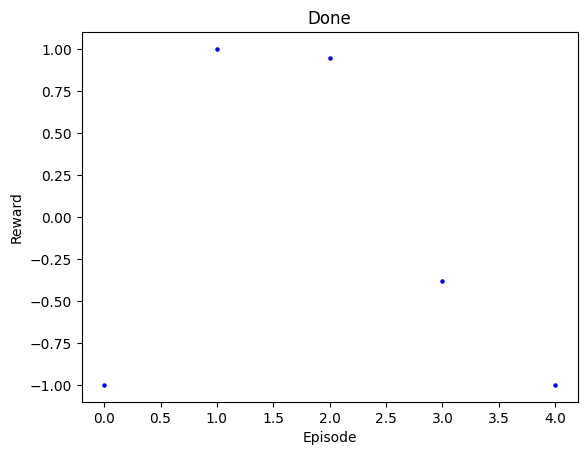

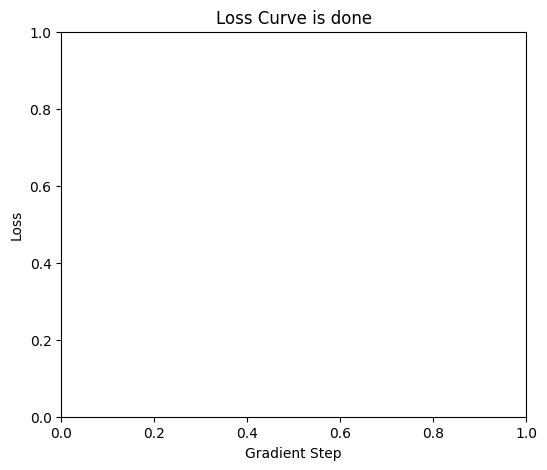

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

In [5]:
env = Poker()

is_ipython = 'inline' in matplotlib.get_backend() # checking if program is run in a notebook or command terminal
if is_ipython:
    from IPython import display

plt.ion()

device = torch.device(
    "cuda" if torch.cuda.is_available() else
    "mps" if torch.backends.mps.is_available() else
    "cpu"
)

PokerExperience = namedtuple("PokerExperience", ('observation', 'action', "next_obs", 'reward'))

class MemoryBank(object):
    """
    Replay Buffer!!! 
    """

    def __init__(self, bound):
        self.memory =  deque([], maxlen = bound)
        
    def __len__(self):
        return len(self.memory)
        
    def push(self, *args):
        """
        Notes for push function:
        Adds the new experience to the memory bank
        *args lets the function accept any number of parameters
        """
        self.memory.append(PokerExperience(*args))
        
    def sample(self, size):
        return random.sample(self.memory, size)

def select_action(obs):
    """
    Notes for select_action function:
    Selects the action using an epsilon-greedy policy, where epsilon has a decay rate.
    This leads to high learning in the beginning, but high exploration in the end.
    """
    global hands
    n = random.random()
    eps_upper = EPS_FINAL + (EPS_0 - EPS_FINAL) * math.exp(-1.0 * hands / EPS_DECAY)
    hands += 1
    if n > eps_upper:
        with torch.no_grad():
            q_values = policy_net(obs)
            mask = torch.tensor(env.action_mask(), device = device)
            q_values[:,~mask] = -1e9

            return q_values.argmax(1).view(1,1)
    else:
        legal = np.where(env.action_mask())[0]
        action = random.choice(legal)
        return torch.tensor([[action]], device = device, dtype = torch.long)





#---------------------------------------------------------------------------------
# Hyper and regular parameters
#---------------------------------------------------------------------------------

BATCH = 256
GAMMA = 0.97
EPS_0 = 0.9
EPS_FINAL = 0.01
EPS_DECAY = 113750
TAU = 0.005
ALPHA = 3e-4

n_actions = 7
observation, info = env.reset()
n_obs = len(observation)    

policy_net = PokerDQN(n_obs, n_actions).to(device) 
target_net = PokerDQN(n_obs, n_actions).to(device) 
target_net.load_state_dict(policy_net.state_dict()) 

optimizer = optim.AdamW(policy_net.parameters(), lr = ALPHA, amsgrad = True) 
memory = MemoryBank(275000)
hands = 0



reward_episodes = []
def plot_reward(show_result = False):
    """
    Notes for plot_reward function:
    This is for plotting the result of each episode,
    and creating a simple moving average line of the rewards.
    """
    reward_t = torch.tensor(reward_episodes, dtype = torch.float)
    
    plt.figure(1, figsize=(6,5))
    #plt.subplot(1, 2, 1)
    plt.cla()
    
    if show_result:
        plt.title('Done')
        
    else:
        plt.title('Training...')
        
    plt.xlabel('Episode')
    plt.ylabel('Reward')
    plt.scatter(range(len(reward_t)), reward_t.numpy(), s=5, color='blue')
    
    if len(reward_t) >= 100:
        means = reward_t.unfold(0, 100, 1).mean(1).view(-1)
        means = torch.cat((torch.zeros(99), means))
        plt.plot(means.numpy(), color = "green")
        


loss_history = []
def optimize_model():
    """
    Notes for optimize_model function:
    Loss function and gradient step
    """
    if len(memory) < BATCH:
        return
    transitions = memory.sample(BATCH)
    batch = PokerExperience(*zip(*transitions))

    non_final_mask = torch.tensor(tuple(map(lambda s: s is not None, batch.next_obs)), device=device, dtype=torch.bool)
    non_final_next_obs = torch.cat([s for s in batch.next_obs if s is not None])
    obs_batch = torch.cat(batch.observation)
    action_batch = torch.cat(batch.action)
    reward_batch = torch.cat(batch.reward)

    obs_action_values = policy_net(obs_batch).gather(1, action_batch)

    next_obs_values = torch.zeros(BATCH, device=device)
    with torch.no_grad():
        best_actions = (policy_net(non_final_next_obs).argmax(dim=1, keepdim=True))

        next_obs_values[non_final_mask] = (target_net(non_final_next_obs).gather(1, best_actions).squeeze(1))

    expected_obs_action_values = (next_obs_values * GAMMA) + reward_batch

    criterion = nn.SmoothL1Loss()
    loss = criterion(obs_action_values, expected_obs_action_values.unsqueeze(1))

    optimizer.zero_grad()
    loss.backward()
    torch.nn.utils.clip_grad_value_(policy_net.parameters(), 100)
    optimizer.step()
    loss_history.append(loss.item())


def plot_loss(show_result=False):
    loss_t = torch.tensor(loss_history, dtype=torch.float)

    plt.figure(2, figsize=(6,5))
    #plt.subplot(1, 2, 2)
    plt.cla()
    
    if show_result:
        plt.title("Loss Curve is done")
    else:
        plt.title("Loss Curve loading...")

    plt.xlabel("Gradient Step")
    plt.ylabel("Loss")
    
    if len(loss_t) > 100:
        mean = loss_t.unfold(0, 100, 1).mean(1).view(-1)
        mean = torch.cat((torch.zeros(99), mean))
        plt.plot(mean.numpy(), color = "red")
    
    plt.pause(0.001)
    if is_ipython:
        if not show_result:
            display.display(plt.gcf())
            display.clear_output(wait=True)
        else:
            display.display(plt.gcf())

#-----------------------------------------------------------------------------------------------------
# Actual training
#-----------------------------------------------------------------------------------------------------

num_episodes = 87500

for episode in range(num_episodes):
    obs, info = env.reset()
    obs = torch.tensor(obs, dtype=torch.float32, device=device).unsqueeze(0)
    total_reward = 0
    
    for t in count():
        action = select_action(obs)
        current_obs = obs
        obs, reward, terminated, truncated, info = env.step(action.item())

        reward = reward / env.stack         
        reward = torch.tensor([reward], dtype=torch.float32, device=device)

        done = terminated or truncated

        if terminated:
            next_obs = None
        else:
            next_obs = torch.tensor(obs, dtype=torch.float32, device=device).unsqueeze(0)

        memory.push(current_obs, action, next_obs, reward)
        obs = next_obs

        optimize_model()

        target_net_obs_dict = target_net.state_dict()
        policy_net_obs_dict = policy_net.state_dict()
        for key in policy_net_obs_dict:
            target_net_obs_dict[key] = policy_net_obs_dict[key]*TAU + target_net_obs_dict[key]*(1-TAU)
        target_net.load_state_dict(target_net_obs_dict)
        total_reward += reward.item()
        if done:
            reward_episodes.append(total_reward)
            
            if episode % 1000 == 0: # can change the modulo factor, the bigger the less often the plot is updated, which will also decrease runtime of code
                plot_reward()
                plot_loss()
            
            break
            
weights = torch.save(policy_net.state_dict(), "policy_net_weights.pth")
print('Complete')
plot_reward(show_result=True)
plot_loss(show_result=True)
plt.ioff()
plt.show()

In [3]:
env = Poker()
device = torch.device(
    "cuda" if torch.cuda.is_available() else
    "cpu"
)
observation, null = env.reset()

policy_net = PokerDQN(len(observation), env.action_space.n).to(device)
policy_net.load_state_dict(torch.load("policy_net_weights.pth", map_location = device))
policy_net.eval()

def choose_action(obs):
    obs = torch.tensor(obs, dtype=torch.float32, device=device).unsqueeze(0)
    
    with torch.no_grad():
        q_values = policy_net(obs)
        mask = torch.tensor(env.action_mask(), device=device)
        q_values[:,~mask] = -1e10
        action = q_values.argmax(dim=1).item()
        
    return action

    
class Play:

    def __init__(self):
        
        self.button = None
        self.stack = None
        self.starting_stack = None

        self.deck = None
        self.street = None
        self.board = None
        self.h1 = None
        self.h2 = None

        self.opp_stack = None
        self.opp_raises = None
        self.opp_calls = None
        self.opp_action = None

        self.bet_history = None

        self.pot = None

        self.hero_stack = None
        self.win_rate = None

        self.betting_ongoing = None
        self.position = None

    
    def obs_vector(self):
        call_amount = abs(self.bet_history[1] - self.bet_history[0])
        
        if call_amount == 0:
            pot_odds = 0
        else:
            pot_odds = call_amount / (self.pot + call_amount)

        opp_agg = min(self.opp_raises / max(self.opp_calls, 1), 5)
        return np.array([
            self.win_rate, 
            self.stack / self.starting_stack,
            self.pot / (2*self.stack), # normalized pot
            self.hero_stack / self.stack, # normalized hero stack
            min(self.hero_stack, self.opp_stack) / self.stack, # normalized effective stack
            self.position,
            pot_odds, # pot odds (doesn't inlcude opponent last bet as it is already accounted for in the pot)
            opp_agg, 
            self.street / 3,
            self.opp_action,
            self.betting_ongoing
        ], dtype = np.float32)
    

    def advance_street(self):
        
        self.street += 1
        self.bet_history = deque([0,0],maxlen=2)
        
        if self.street == 1:
            flop1, flop2, flop3 = input("What are the flop cards sir?").split()
            cards = [Card.new(flop1), Card.new(flop2), Card.new(flop3)]
            self.board.extend(cards)
            self.remove(flop1, flop2, flop3)
        elif self.street == 2:
            turn = input("What is the turn card sir?")
            self.board.append(Card.new(turn))
            self.remove(turn)
        elif self.street == 3:
            river = input("What is the river card sir?")
            self.board.append(Card.new(river))
            self.remove(river)

    
    def compute_win_rate(self):
        if self.street == 0:
            self.win_rate = simulate_preflop(self.h1, self.h2)
            return self.win_rate
            
        elif self.street == 1:
            board = [Card.int_to_str(card) for card in self.board]
            self.win_rate = simulate_preturn(self.h1, self.h2, board[0], board[1], board[2])
            return self.win_rate
            
        elif self.street == 2:
            board = [Card.int_to_str(card) for card in self.board]
            self.win_rate = simulate_preriver(self.h1, self.h2, board[0], board[1], board[2], board[3])
            return self.win_rate
        else:
            board = [Card.int_to_str(card) for card in self.board]
            self.win_rate = simulate_prereveal(self.h1, self.h2, board[0], board[1], board[2], board[3], board[4])
            return self.win_rate



    def done(self, action):
        call_amount = self.bet_history[1] - self.bet_history[0]
        if call_amount == 0 or self.opp_action == 0 or action == 0:
            self.betting_ongoing = False
        else:
            self.betting_ongoing = True


    def chip_mover(self, player, amount):
        if player == "hero":
            self.hero_stack -= amount
            self.pot += amount
        else:
            self.opp_stack -= amount
            self.pot += amount

        

    def apply_action(self, action):

        if action == 0:
            return
            
        elif action == 1:
            call_amount = self.bet_history[1] - self.bet_history[0]
            self.chip_mover("hero", call_amount)
            
        elif action in (2, 3, 4, 5):
            call_amount = self.bet_history[1] - self.bet_history[0]

            if action == 2:
                bet_amount = call_amount + 0.33*self.pot
                self.bet_history.append(bet_amount)
                
            elif action == 3:
                bet_amount = call_amount + 0.67*self.pot
                self.bet_history.append(bet_amount)
                
            elif action == 4:
                bet_amount = call_amount + self.pot
                self.bet_history.append(bet_amount)
                
            elif action == 5:
                bet_amount = call_amount + 1.25*self.pot
                self.bet_history.append(bet_amount)

            self.chip_mover("hero", bet_amount)
            
        elif action == 6:
            self.chip_mover("hero", self.hero_stack)
            self.bet_history.append(self.hero_stack)
    


    def showdown(self):
        ui = input("Did you win or lose?")
        if ui == "w":
            return True
        else:
            return False
        

    def what_opp(self):
        action = input("What is your opponent's action sir?")
        if action == "fold":
            action = 0 
            
        elif action == "call" or action == "check":
            self.opp_calls += 1
            
            if action == "call":
                amount = abs(self.bet_history[1] - self.bet_history[0])
                
            else:
                amount = 0
            self.chip_mover("opp", amount)
            self.bet_history.append(self.bet_history[1])
            action = 1
            
        elif action == "bet" or action == "raise":
            self.opp_raises += 1
            amount = float(input("What is the the amount sir?"))
            self.chip_mover("opp", amount)
            self.bet_history.append(amount)
            
            if amount <= 0.33*self.pot:
                action = 2
                
            elif amount <= 0.67*self.pot:
                action = 3
                
            elif amount <= self.pot:
                action = 4
                
            else:
                action = 5
                
        elif action == "all-in":
            self.bet_history.append(self.opp_stack)
            self.chip_mover("opp", self.opp_stack)
            action = 6

        return action
        
            
    def remove(self, *args):
        for c in args:
            self.deck.cards.remove(Card.new(c))

            
    def what_action(self, action):
        if action == 0:
            self.apply_action(action)
            return "fold"
        elif action == 1:
            self.apply_action(action)
            return "call"
        elif action == 2:
            self.apply_action(action)
            return f"bet/raise {self.pot*0.33}"
        elif action == 3:
            self.apply_action(action)
            return f"bet/raise {self.pot*0.67}"
        elif action == 4:
            self.apply_action(action)
            return f"bet/raise {self.pot}"
        elif action == 5:
            self.apply_action(action)
            return f"bet/raise {self.pot*1.25}"
        else:
            self.apply_action(action)
            return "all-in"

            
    def main(self):
#------------------------------------------------------------------------------
# START GAME
#------------------------------------------------------------------------------
        done = False

        blind = input("As of right now, are you the small blind sir?")
        small_blind = float(input("How much is small blind?"))
        self.button = 0 if blind == "yes" else 1
        big_blind = 2*small_blind
        stack = float(input("What will stack amount be sir?"))
        self.starting_stack = stack
        self.stack = stack
        self.hero_stack = stack
        self.opp_stack = stack
        count = 0
        
        while not done:      
#-------------------------------------------------------------------------------
# NEW HAND
#-------------------------------------------------------------------------------
            hand_over = False
            count += 1
            self.h1 = None
            self.h2 = None
            self.deck = Deck()
            self.h1, self.h2 = input("Your cards sir?").split()
            self.remove(self.h1, self.h2)
            
            self.pot = small_blind + big_blind
            if (count % 2 != 0 and self.button == 0) or (count % 2 == 0 and self.button == 1):
                self.bet_history = deque([small_blind, big_blind], maxlen=2)
                self.position = 0
            else:
                self.bet_history = deque([big_blind, small_blind], maxlen=2)
                self.position = 1

            self.street = 0
            self.stack = self.hero_stack
            self.board = []
            self.opp_calls = 0
            self.opp_raises = 0
            self.opp_action = 1
            self.betting_ongoing = True
            while not hand_over:
                
                if self.street == 0:
                    self.compute_win_rate()
                        
                    if self.position == 0:
                        while self.betting_ongoing:
                            obs = self.obs_vector()
                            action = choose_action(obs)
                            action_int = action
                            action = self.what_action(action_int)
                            print(action)
                            self.done(action_int)
                            if self.betting_ongoing == False:
                                break
                                
                            self.opp_action = self.what_opp()
                            self.done(action_int)
                            
                    else:
                        while self.betting_ongoing:
                            self.opp_action = self.what_opp()
                            self.done(action_int)
                            if self.betting_ongoing == False:
                                break
                                
                            obs = self.obs_vector()
                            action = choose_action(obs)
                            action_int = action
                            action = self.what_action(action_int)
                            print(action)
                            
                            self.done(action_int)
                            
                elif self.street == 1:
                    self.compute_win_rate()
                        
                    if self.position == 1:
                        while self.betting_ongoing:
                            obs = self.obs_vector()
                            action = choose_action(obs)
                            action_int = action
                            action = self.what_action(action_int)
                            print(action)
                            self.done(action_int)
                            if self.betting_ongoing == False:
                                break
                                
                            self.opp_action = self.what_opp()
                            self.done(action_int)
                            
                    else:
                        while self.betting_ongoing:
                            self.opp_action = self.what_opp()
                            self.done(action_int)
                            if self.betting_ongoing == False:
                                break
                                
                            obs = self.obs_vector()
                            action = choose_action(obs)
                            action_int = action
                            action = self.what_action(action_int)
                            print(action)
                            
                            self.done(action_int)  
                            
                elif self.street == 2:
                    self.compute_win_rate()
                        
                    if self.position == 1:
                        while self.betting_ongoing:
                            obs = self.obs_vector()
                            action = choose_action(obs)
                            action_int = action
                            action = self.what_action(action_int)
                            print(action)
                            self.done(action_int)
                            if self.betting_ongoing == False:
                                break
                                
                            self.opp_action = self.what_opp()
                            self.done(action_int)
                            
                    else:
                        while self.betting_ongoing:
                            self.opp_action = self.what_opp()
                            self.done(action_int)
                            if self.betting_ongoing == False:
                                break
                                
                            obs = self.obs_vector()
                            action = choose_action(obs)
                            action_int = action
                            action = self.what_action(action_int)
                            print(action)
                            
                            self.done(action_int) 

                elif self.street == 3:
                    self.compute_win_rate()
                        
                    if self.position == 1:
                        while self.betting_ongoing:
                            obs = self.obs_vector()
                            action = choose_action(obs)
                            action_int = action
                            action = self.what_action(action_int)
                            print(action)
                            self.done(action_int)
                            if self.betting_ongoing == False:
                                break
                                
                            self.opp_action = self.what_opp()
                            self.done(action_int)
                            
                    else:
                        while self.betting_ongoing:
                            self.opp_action = self.what_opp()
                            self.done(action_int)
                            if self.betting_ongoing == False:
                                break
                                
                            obs = self.obs_vector()
                            action = choose_action(obs)
                            action_int = action
                            action = self.what_action(action_int)
                            print(action)
                            
                            self.done(action_int)
                    
                    
                if action == 0:
                    self.opp_stack += self.pot
                    hand_over = True
                    
                elif self.opp_action == 0:
                    self.hero_stack += self.pot
                    hand_over = True
                    
                elif self.street == 3 or self.opp_stack <= 0 or self.hero_stack <= 0:
                    win = self.showdown()
                    if win is True:
                        self.hero_stack += self.pot
                    else:
                        self.opp_stack += self.pot
                       
                    hand_over = True

                    
                if not hand_over:
                    self.advance_street()
                
            done = True if input("Will that be all sir?") == "yes" else False

    

In [ ]:
play = Play()
play.main()

As of right now, are you the small blind sir? yes
How much is small blind? 10
What will stack amount be sir? 500
Your cards sir? 7h 2d


all-in
